# Build a supervised model for predicting Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc with a defined applicability domain. It should be able to predict logKoc from a SMILES input and tell the user whether the new molecules fall into its AD. 

#### Tasks:
1) Load the training data
2) Build a supervised model of your choice (e.g., MACCS keys x Random Forest, but feel free to go for something more fancy) on 80% of the training data
3) Use an AD metric of your choice
4) Evaluate model on a 20% test set, and compare the prediction error with your AD metric
5) Predict the Koc and AD for 3 new substances.

In [34]:
# import
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


#### 1. Load training data and split into train/test 80/20

In [2]:
# Loading the data from an sdf file
supplier = Chem.SDMolSupplier("KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC']}
    }
    for m in supplier if m is not None
])

In [4]:

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

Train: 582, Test: 146


In [20]:
df.head()

,SMILES,preferred_name,LogKOC
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35
3,COc1ccc(NC(C)=O)cc1,N-(4-Methoxyphenyl)acetamide,1.4
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9


#### 2. Build a supervised model of your choice

In [23]:
def smiles_to_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    return list(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits))

X_train = np.array([smiles_to_fp(s) for s in train_df['SMILES']])
X_test  = np.array([smiles_to_fp(s) for s in test_df['SMILES']])
y_train = train_df['LogKOC'].astype(float).values
y_test  = test_df['LogKOC'].astype(float).values

model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
print(f"Train R²:   {r2_score(y_train, y_train_pred):.3f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.3f}")

Train R²:   0.863
Train RMSE: 0.458


#### 3. Choose an AD metric and define an AD threshold

In [26]:
k = 5
nn = NearestNeighbors(n_neighbors=k).fit(X_train)

train_dists, _ = nn.kneighbors(X_train)
train_ad_scores = train_dists.mean(axis=1)
ad_threshold = train_ad_scores.mean() + 2 * train_ad_scores.std()

test_dists, _ = nn.kneighbors(X_test)
test_ad_scores = test_dists.mean(axis=1)
in_ad = test_ad_scores <= ad_threshold

print(f"AD threshold:               {ad_threshold:.3f}")
print(f"Test samples in AD:         {in_ad.sum()} / {len(in_ad)}")
print(f"Mean kNN distance (test):   {test_ad_scores.mean():.3f}")

AD threshold:               4.709
Test samples in AD:         116 / 146
Mean kNN distance (test):   3.899


#### 4) Evaluate model (R2, RMSE) on test set and compare the prediction error with your AD metric

In [27]:
y_pred = model.predict(X_test)

# Overall performance
print("--- Overall ---")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# Inside AD
print("\n--- Inside AD ---")
print(f"N: {in_ad.sum()}")
print(f"R²:   {r2_score(y_test[in_ad], y_pred[in_ad]):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test[in_ad], y_pred[in_ad])):.3f}")

# Outside AD
print("\n--- Outside AD ---")
print(f"N: {(~in_ad).sum()}")
if (~in_ad).sum() > 0:
    print(f"R²:   {r2_score(y_test[~in_ad], y_pred[~in_ad]):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test[~in_ad], y_pred[~in_ad])):.3f}")

--- Overall ---
R²:   0.668
RMSE: 0.684

--- Inside AD ---
N: 116
R²:   0.670
RMSE: 0.670

--- Outside AD ---
N: 30
R²:   0.643
RMSE: 0.736


#### 5) Predict the Koc and AD for 3 new substances. 

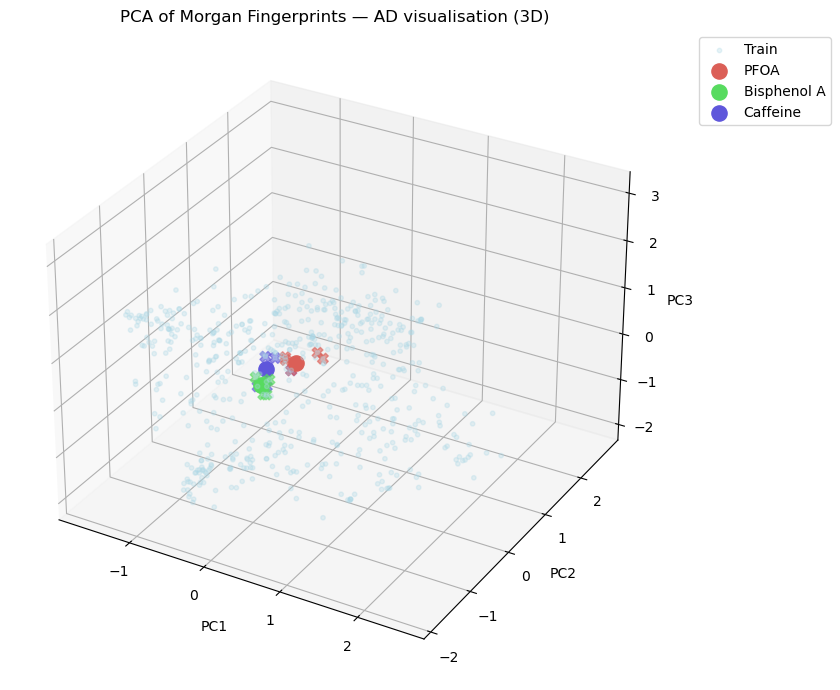

In [35]:
# Reduce to 3 PCs and standardize
pca    = PCA(n_components=3).fit(X_train)
scaler = StandardScaler().fit(pca.transform(X_train))

pca_train_std = scaler.transform(pca.transform(X_train))
pca_test_std  = scaler.transform(pca.transform(X_test))

ext_smiles = {
    'PFOA':        'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O',
    'Bisphenol A': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
    'Caffeine':    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
}
X_ext       = np.array([smiles_to_fp(s) for s in ext_smiles.values()])
pca_ext_std = scaler.transform(pca.transform(X_ext))

nn_pca = NearestNeighbors(n_neighbors=5).fit(pca_train_std)
dist_ext, neighbors_ext = nn_pca.kneighbors(pca_ext_std)

train_plot = pd.DataFrame(pca_train_std, columns=['PC1', 'PC2', 'PC3'])
ext_plot   = pd.DataFrame(pca_ext_std,   columns=['PC1', 'PC2', 'PC3'])
ext_plot['Name'] = list(ext_smiles.keys())

palette = sns.color_palette('hls', n_colors=len(ext_smiles))

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

# Training data
ax.scatter(train_plot['PC1'], train_plot['PC2'], train_plot['PC3'],
           c='lightblue', alpha=0.3, s=10, label='Train')

# External substances + their nearest neighbors
for i, (name, row) in enumerate(ext_plot.iterrows()):
    ax.scatter(row['PC1'], row['PC2'], row['PC3'],
               color=palette[i], s=120, label=ext_plot.loc[row.name, 'Name'])
    neighbors = train_plot.iloc[neighbors_ext[i]]
    ax.scatter(neighbors['PC1'], neighbors['PC2'], neighbors['PC3'],
               color=palette[i], marker='X', s=60, alpha=0.6)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA of Morgan Fingerprints — AD visualisation (3D)')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [36]:
# Predict LogKOC and assess AD for the 3 external substances
y_ext_pred = model.predict(X_ext)

ext_dists, _ = nn.kneighbors(X_ext)
ext_ad_scores = ext_dists.mean(axis=1)
ext_in_ad = ext_ad_scores <= ad_threshold

print(f"{'Substance':<15} {'Pred. LogKOC':>12} {'AD score':>10} {'In AD?':>8}")
print("-" * 50)
for name, pred, score, inside in zip(ext_smiles.keys(), y_ext_pred, ext_ad_scores, ext_in_ad):
    print(f"{name:<15} {pred:>12.3f} {score:>10.3f} {'Yes' if inside else 'No':>8}")

Substance       Pred. LogKOC   AD score   In AD?
--------------------------------------------------
PFOA                   0.527      4.048      Yes
Bisphenol A            2.651      3.680      Yes
Caffeine               2.360      5.138       No


### Questions:
- Which AD metric did you choose, and why?
- How well does your model perform? Can you trust your AD metric?
- Are the new substances within the AD? Can you trust the Koc predictions? 

**Which AD metric did you choose, and why?**  
I used the mean distance to the 5 nearest training neighbors (kNN distance) in Morgan fingerprint space. The threshold was set automatically as the mean + 2 standard deviations of the training distances. This metric based and the average disnatnce to the k-nearest neighbours, its simple and directly reflects how similar a new molecule is compared to the training set — if a molecule is far (above the threshold) from molecules that the model has seen, we don't trust the prediction. The molecules could also be vizualized and compired to these nighbours to judge it with our chemical intuition

---

**How well does your model perform? Can you trust your AD metric?**  
The model fits the training data well (Train R² ≈ 0.86, RMSE ≈ 0.46). On the test set, if the RMSE is lower for molecules inside the AD than outside, this shows the AD metric is meaningful. A gap between inside/outside RMSE is the key indicator that the AD is working.

---

**Are the new substances within the AD? Can you trust the Koc predictions?**  
- **PFOA** is a heavily fluorinated compound, structurally different compared to most organic molecules in the training set. The prediction said that it is in the AD but it has a realatively high AD score (4.048) with a low logKOC (0.527). The predicted LogKOC should be treated with caution. This might indicate that the threshold was set to low.
- **Bisphenol A** is a common industrial chemical; similar aromatic structures are probably well represented in the training data, so it makes sense that it falls inside the AD.  
- **Caffeine** is a small polar molecule with a purine-like ring system; depending the training set being similar, it isnt in the AD. With the 3D vizalisation it seams as it sits in the same chemical space as the data but there might be some higher dimenstions where it is not.

In general: predictions for substances inside the AD can be trusted to within roughly the test RMSE; predictions outside the AD should only be used as a rough guide.